# Week 8 Development Notebook

## 1. Environment setup and sanity check

In [118]:
# TODO: Verify environment and imports.
# Outcome: confirm LunarLander-v3 loads, action/observation spaces are correct,
# SB3 DQN can be instantiated with device="mps", and a random policy baseline
# reward is logged.
# DONE

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["PYTHONWARNINGS"] = "ignore"

import gymnasium as gym
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_vec_env

# --- Device ---
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

# --- Environment sanity check ---
env = gym.make("LunarLander-v3")
obs, _ = env.reset()
print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Sample obs shape:  {obs.shape}")
env.close()

# --- DQN instantiation check ---
vec_env = make_vec_env("LunarLander-v3", n_envs=1)
model = DQN(
    policy="MlpPolicy",
    env=vec_env,
    device=device,
    verbose=0,
)
print(f"DQN policy device: {next(model.policy.parameters()).device}")
vec_env.close()

# --- Random policy baseline ---
env = gym.make("LunarLander-v3")
N_EPISODES = 20
returns = []
for _ in range(N_EPISODES):
    obs, _ = env.reset()
    done = False
    total_reward = 0.0
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        done = terminated or truncated
    returns.append(total_reward)
env.close()

print(f"\nRandom policy baseline ({N_EPISODES} episodes):")
print(f"  Mean return : {np.mean(returns):.1f}")
print(f"  Std return  : {np.std(returns):.1f}")
print(f"  Min / Max   : {np.min(returns):.1f} / {np.max(returns):.1f}")

Device: mps
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space:      Discrete(4)
Sample obs shape:  (8,)
DQN policy device: mps:0

Random policy baseline (20 episodes):
  Mean return : -153.2
  Std return  : 106.1
  Min / Max   : -384.3 / 31.7


## 2. Baseline DQN

The initial baseline used SB3 defaults, which produced unstable learning that plateaued well below the +200 solved threshold. All hyperparameter sweeps showed marginal variation around a poor baseline, making it difficult to draw meaningful conclusions.

We adopted the [rl-baselines3-zoo](https://github.com/DLR-RM/rl-baselines3-zoo) tuned configuration for `LunarLander-v3` as the new baseline (`hyperparams/dqn.yml`). This config is known to reliably solve the environment within 100k timesteps and provides a stronger foundation for controlled experiments — sweeps now show meaningful degradation or improvement around a working solution.

Key differences from SB3 defaults:

| Parameter | SB3 Default | Zoo Baseline |
|---|---|---|
| `learning_rate` | 1e-4 | 6.3e-4 |
| `buffer_size` | 1,000,000 | 50,000 |
| `batch_size` | 32 | 128 |
| `target_update_interval` | 10,000 | 250 |
| `exploration_fraction` | 0.10 | 0.12 |
| `exploration_final_eps` | 0.05 | 0.10 |
| `gradient_steps` | 1 | -1 (match env steps) |
| `net_arch` | [64, 64] | [256, 256] |

In [119]:
# --- Experiment controls (change here, applies to all training cells) ---
SMOKE           = False
TOTAL_TIMESTEPS = 500         if SMOKE else 100_000
SEEDS           = [0]         if SMOKE else list(range(20))
VERBOSE         = 1           if SMOKE else 0

BASELINE_CONFIG = dict(
    learning_rate          = 6.3e-4,
    buffer_size            = 50_000,
    batch_size             = 128,
    gamma                  = 0.99,
    exploration_fraction   = 0.12,
    exploration_final_eps  = 0.10,
    target_update_interval = 250,
    train_freq             = 4,
    gradient_steps         = -1,
    policy_kwargs          = dict(net_arch=[256, 256]),
)

print(f"SMOKE={SMOKE} | TOTAL_TIMESTEPS={TOTAL_TIMESTEPS:,} | SEEDS={SEEDS} | VERBOSE={VERBOSE}")
print(f"BASELINE_CONFIG={BASELINE_CONFIG}")

SMOKE=False | TOTAL_TIMESTEPS=100,000 | SEEDS=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] | VERBOSE=0
BASELINE_CONFIG={'learning_rate': 0.00063, 'buffer_size': 50000, 'batch_size': 128, 'gamma': 0.99, 'exploration_fraction': 0.12, 'exploration_final_eps': 0.1, 'target_update_interval': 250, 'train_freq': 4, 'gradient_steps': -1, 'policy_kwargs': {'net_arch': [256, 256]}}


In [120]:
# TODO: Train baseline DQN across 5 seeds using rl-baselines3-zoo config.
# Outcome: learning curves (episode reward vs timestep) for all 5 seeds,
# mean final performance logged, results persisted to data/baseline/.
# DONE

import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym

device = "mps" if torch.backends.mps.is_available() else "cpu"
DATA_DIR = "../data/baseline"
os.makedirs(DATA_DIR, exist_ok=True)

class EpisodeRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.curve = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.curve.append((self.num_timesteps, info["episode"]["r"]))
        return True

def make_monitored_env(seed):
    def _init():
        env = gym.make("LunarLander-v3")
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _init

# --- Verify config before training ---
_test_env = make_vec_env("LunarLander-v3", n_envs=1, seed=0)
_test_model = DQN("MlpPolicy", _test_env, device=device, verbose=0, **BASELINE_CONFIG)
print("Baseline DQN config (zoo):")
print(f"  learning_rate         : {_test_model.learning_rate}")
print(f"  buffer_size           : {_test_model.buffer_size}")
print(f"  batch_size            : {_test_model.batch_size}")
print(f"  target_update_interval: {_test_model.target_update_interval}")
print(f"  exploration_fraction  : {_test_model.exploration_fraction}")
print(f"  exploration_final_eps : {_test_model.exploration_final_eps}")
print(f"  gradient_steps        : {_test_model.gradient_steps}")
print(f"  gamma                 : {_test_model.gamma}")
print(f"  net_arch              : {BASELINE_CONFIG['policy_kwargs']['net_arch']}")
print(f"  device                : {device}")
print(f"  SMOKE                 : {SMOKE}")
_test_env.close()
del _test_model

print(f"\nBaseline | {TOTAL_TIMESTEPS:,} timesteps | {len(SEEDS)} seeds")
final_rewards = []
run_start = time.time()

for seed in SEEDS:
    fname = f"{DATA_DIR}/curve_baseline_seed{seed}.npy"
    if os.path.exists(fname):
        curve = np.load(fname)
        final_rew = np.mean(curve[-10:, 1]) if len(curve) >= 10 else np.mean(curve[:, 1])
        final_rewards.append(final_rew)
        print(f"  seed {seed}: on disk, final={final_rew:.1f}")
        continue

    t0 = time.time()
    env = DummyVecEnv([make_monitored_env(seed)])
    model = DQN("MlpPolicy", env, device=device, verbose=VERBOSE, seed=seed, **BASELINE_CONFIG)
    cb = EpisodeRewardCallback()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=cb, progress_bar=False)
    env.close()
    elapsed = time.time() - t0

    curve = np.array(cb.curve)
    np.save(fname, curve)

    if len(curve) > 0:
        final_rew = np.mean(curve[-10:, 1]) if len(curve) >= 10 else np.mean(curve[:, 1])
        final_rewards.append(final_rew)
        print(f"  seed {seed}: episodes={len(curve)}, final={final_rew:.1f}  [{elapsed:.0f}s]")
    else:
        print(f"  seed {seed}: no episodes completed  [{elapsed:.0f}s]")

total_elapsed = time.time() - run_start
print(f"\nTotal wall time: {total_elapsed:.0f}s ({total_elapsed/60:.1f} min)")
print(f"Baseline summary: mean={np.mean(final_rewards):.1f}  std={np.std(final_rewards):.1f}")

Baseline DQN config (zoo):
  learning_rate         : 0.00063
  buffer_size           : 50000
  batch_size            : 128
  target_update_interval: 250
  exploration_fraction  : 0.12
  exploration_final_eps : 0.1
  gradient_steps        : -1
  gamma                 : 0.99
  net_arch              : [256, 256]
  device                : mps
  SMOKE                 : False

Baseline | 100,000 timesteps | 20 seeds
  seed 0: on disk, final=-40.4
  seed 1: on disk, final=-2.7
  seed 2: on disk, final=44.3
  seed 3: on disk, final=225.1
  seed 4: on disk, final=208.8
  seed 5: on disk, final=45.5
  seed 6: on disk, final=178.8
  seed 7: on disk, final=-206.4
  seed 8: on disk, final=180.2
  seed 9: on disk, final=150.3
  seed 10: on disk, final=247.6
  seed 11: on disk, final=158.9
  seed 12: on disk, final=162.1
  seed 13: on disk, final=213.8
  seed 14: on disk, final=138.7
  seed 15: on disk, final=162.0
  seed 16: on disk, final=-291.7
  seed 17: on disk, final=202.0
  seed 18: on disk, f

## 3. Hyperparameter sweeps

### Learning Rate sweeps

In [121]:
# TODO: Sweep learning rate across 3 values (2e-4, 6.3e-4, 2e-3), 5 seeds each.
# Outcome: learning curves per value, results persisted to data/sweep_lr/.
# DONE

import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym

device = "mps" if torch.backends.mps.is_available() else "cpu"
DATA_DIR = "../data/sweep_lr"
os.makedirs(DATA_DIR, exist_ok=True)
LR_VALUES = [2e-4, 2e-3]

class EpisodeRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.curve = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.curve.append((self.num_timesteps, info["episode"]["r"]))
        return True

def make_monitored_env(seed):
    def _init():
        env = gym.make("LunarLander-v3")
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _init

print(f"Learning rate sweep | SMOKE={SMOKE} | {TOTAL_TIMESTEPS:,} timesteps | {len(SEEDS)} seeds")
print(f"LR values: {LR_VALUES}\n")

for lr in LR_VALUES:
    lr_tag = f"lr{lr:.0e}"
    expected_files = [f"{DATA_DIR}/curve_{lr_tag}_seed{s}.npy" for s in SEEDS]

    if all(os.path.exists(f) for f in expected_files):
        print(f"  lr={lr:.0e}: results on disk, skipping.")
        continue

    print(f"  lr={lr:.0e}: training {len(SEEDS)} seeds ...")
    run_start = time.time()

    for seed in SEEDS:
        t0 = time.time()
        env = DummyVecEnv([make_monitored_env(seed)])
        model = DQN(
            policy="MlpPolicy",
            env=env,
            device=device,
            verbose=VERBOSE,
            seed=seed,
            **{**BASELINE_CONFIG, "learning_rate": lr},
        )
        cb = EpisodeRewardCallback()
        model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=cb, progress_bar=False)
        env.close()
        elapsed = time.time() - t0

        curve = np.array(cb.curve)
        np.save(f"{DATA_DIR}/curve_{lr_tag}_seed{seed}.npy", curve)

        final_rew = np.mean(curve[-10:, 1]) if len(curve) >= 10 else (np.mean(curve[:, 1]) if len(curve) > 0 else float("nan"))
        print(f"    seed {seed}: episodes={len(curve)}, final mean return = {final_rew:.1f}  [{elapsed:.0f}s]")

    print(f"  lr={lr:.0e} total: {time.time()-run_start:.0f}s\n")

Learning rate sweep | SMOKE=False | 100,000 timesteps | 20 seeds
LR values: [0.0002, 0.002]

  lr=2e-04: results on disk, skipping.
  lr=2e-03: results on disk, skipping.


### Exploration Fraction sweeps

In [122]:
# TODO: Sweep exploration fraction across 3 values (0.06, 0.12, 0.24), 5 seeds each.
# Outcome: learning curves per value, results persisted to data/sweep_exploration/.
# DONE

import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym

device = "mps" if torch.backends.mps.is_available() else "cpu"
DATA_DIR = "../data/sweep_exploration"
os.makedirs(DATA_DIR, exist_ok=True)
EF_VALUES = [0.06, 0.24]

class EpisodeRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.curve = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.curve.append((self.num_timesteps, info["episode"]["r"]))
        return True

def make_monitored_env(seed):
    def _init():
        env = gym.make("LunarLander-v3")
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _init

print(f"Exploration fraction sweep | SMOKE={SMOKE} | {TOTAL_TIMESTEPS:,} timesteps | {len(SEEDS)} seeds")
print(f"Exploration fraction values: {EF_VALUES}\n")

for ef in EF_VALUES:
    ef_tag = f"ef{ef:.2f}"
    expected_files = [f"{DATA_DIR}/curve_{ef_tag}_seed{s}.npy" for s in SEEDS]

    if all(os.path.exists(f) for f in expected_files):
        print(f"  ef={ef}: results on disk, skipping.")
        continue

    print(f"  ef={ef}: training {len(SEEDS)} seeds ...")
    run_start = time.time()

    for seed in SEEDS:
        t0 = time.time()
        env = DummyVecEnv([make_monitored_env(seed)])
        model = DQN(
            policy="MlpPolicy",
            env=env,
            device=device,
            verbose=VERBOSE,
            seed=seed,
            **{**BASELINE_CONFIG, "exploration_fraction": ef},
        )
        cb = EpisodeRewardCallback()
        model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=cb, progress_bar=False)
        env.close()
        elapsed = time.time() - t0

        curve = np.array(cb.curve)
        np.save(f"{DATA_DIR}/curve_{ef_tag}_seed{seed}.npy", curve)

        final_rew = np.mean(curve[-10:, 1]) if len(curve) >= 10 else (np.mean(curve[:, 1]) if len(curve) > 0 else float("nan"))
        print(f"    seed {seed}: episodes={len(curve)}, final mean return = {final_rew:.1f}  [{elapsed:.0f}s]")

    print(f"  ef={ef} total: {time.time()-run_start:.0f}s\n")

Exploration fraction sweep | SMOKE=False | 100,000 timesteps | 20 seeds
Exploration fraction values: [0.06, 0.24]

  ef=0.06: results on disk, skipping.
  ef=0.24: results on disk, skipping.


### Target Update Interval sweeps

In [123]:
# TODO: Sweep target update interval across 3 values (125, 250, 500), 5 seeds each.
# Outcome: learning curves per value, results persisted to data/sweep_target_update/.
# DONE

import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym

device = "mps" if torch.backends.mps.is_available() else "cpu"
DATA_DIR = "../data/sweep_target_update"
os.makedirs(DATA_DIR, exist_ok=True)
TUI_VALUES = [125, 500]

class EpisodeRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.curve = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.curve.append((self.num_timesteps, info["episode"]["r"]))
        return True

def make_monitored_env(seed):
    def _init():
        env = gym.make("LunarLander-v3")
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _init

print(f"Target update interval sweep | SMOKE={SMOKE} | {TOTAL_TIMESTEPS:,} timesteps | {len(SEEDS)} seeds")
print(f"Target update interval values: {TUI_VALUES}\n")

for tui in TUI_VALUES:
    tui_tag = f"tui{tui}"
    expected_files = [f"{DATA_DIR}/curve_{tui_tag}_seed{s}.npy" for s in SEEDS]

    if all(os.path.exists(f) for f in expected_files):
        print(f"  tui={tui}: results on disk, skipping.")
        continue

    print(f"  tui={tui}: training {len(SEEDS)} seeds ...")
    run_start = time.time()

    for seed in SEEDS:
        t0 = time.time()
        env = DummyVecEnv([make_monitored_env(seed)])
        model = DQN(
            policy="MlpPolicy",
            env=env,
            device=device,
            verbose=VERBOSE,
            seed=seed,
            **{**BASELINE_CONFIG, "target_update_interval": tui},
        )
        cb = EpisodeRewardCallback()
        model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=cb, progress_bar=False)
        env.close()
        elapsed = time.time() - t0

        curve = np.array(cb.curve)
        np.save(f"{DATA_DIR}/curve_{tui_tag}_seed{seed}.npy", curve)

        final_rew = np.mean(curve[-10:, 1]) if len(curve) >= 10 else (np.mean(curve[:, 1]) if len(curve) > 0 else float("nan"))
        print(f"    seed {seed}: episodes={len(curve)}, final mean return = {final_rew:.1f}  [{elapsed:.0f}s]")

    print(f"  tui={tui} total: {time.time()-run_start:.0f}s\n")

Target update interval sweep | SMOKE=False | 100,000 timesteps | 20 seeds
Target update interval values: [125, 500]

  tui=125: results on disk, skipping.
  tui=500: results on disk, skipping.


## 4. Ablation studies

In [124]:
# TODO: Ablation -- no target network (target_update_interval=100_000), 5 seeds.
# Outcome: learning curves vs baseline, results persisted to data/ablation_no_target/.
# DONE

import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym

device = "mps" if torch.backends.mps.is_available() else "cpu"
DATA_DIR = "../data/ablation_no_target"
os.makedirs(DATA_DIR, exist_ok=True)

class EpisodeRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.curve = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.curve.append((self.num_timesteps, info["episode"]["r"]))
        return True

def make_monitored_env(seed):
    def _init():
        env = gym.make("LunarLander-v3")
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _init

print(f"Ablation: no target network | {TOTAL_TIMESTEPS:,} timesteps | {len(SEEDS)} seeds")
print(f"target_update_interval=100_000 (never refreshes within run)\n")

run_start = time.time()
for seed in SEEDS:
    fname = f"{DATA_DIR}/curve_no_target_seed{seed}.npy"
    if os.path.exists(fname):
        print(f"  seed {seed}: on disk, skipping.")
        continue
    t0 = time.time()
    env = DummyVecEnv([make_monitored_env(seed)])
    model = DQN("MlpPolicy", env, device=device, verbose=VERBOSE, seed=seed,
                **{**BASELINE_CONFIG, "target_update_interval": 100_000})
    cb = EpisodeRewardCallback()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=cb, progress_bar=False)
    env.close()
    elapsed = time.time() - t0
    curve = np.array(cb.curve)
    np.save(fname, curve)
    final_rew = np.mean(curve[-10:, 1]) if len(curve) >= 10 else (np.mean(curve[:, 1]) if len(curve) > 0 else float("nan"))
    print(f"  seed {seed}: episodes={len(curve)}, final={final_rew:.1f}  [{elapsed:.0f}s]")

print(f"\nTotal wall time: {time.time()-run_start:.0f}s ({(time.time()-run_start)/60:.1f} min)")

Ablation: no target network | 100,000 timesteps | 20 seeds
target_update_interval=100_000 (never refreshes within run)

  seed 0: on disk, skipping.
  seed 1: on disk, skipping.
  seed 2: on disk, skipping.
  seed 3: on disk, skipping.
  seed 4: on disk, skipping.
  seed 5: on disk, skipping.
  seed 6: on disk, skipping.
  seed 7: on disk, skipping.
  seed 8: on disk, skipping.
  seed 9: on disk, skipping.
  seed 10: on disk, skipping.
  seed 11: on disk, skipping.
  seed 12: on disk, skipping.
  seed 13: on disk, skipping.
  seed 14: on disk, skipping.
  seed 15: on disk, skipping.
  seed 16: on disk, skipping.
  seed 17: on disk, skipping.
  seed 18: on disk, skipping.
  seed 19: on disk, skipping.

Total wall time: 0s (0.0 min)


In [125]:
# TODO: Ablation -- no experience replay (buffer_size=1, batch_size=1), 5 seeds.
# Outcome: learning curves vs baseline, results persisted to data/ablation_no_replay/.
# DONE

import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym

device = "mps" if torch.backends.mps.is_available() else "cpu"
DATA_DIR = "../data/ablation_no_replay"
os.makedirs(DATA_DIR, exist_ok=True)

class EpisodeRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.curve = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.curve.append((self.num_timesteps, info["episode"]["r"]))
        return True

def make_monitored_env(seed):
    def _init():
        env = gym.make("LunarLander-v3")
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _init

print(f"Ablation: no experience replay | {TOTAL_TIMESTEPS:,} timesteps | {len(SEEDS)} seeds")
print(f"buffer_size=1, batch_size=1, gradient_steps=1 (online Q-learning)\n")

run_start = time.time()
for seed in SEEDS:
    fname = f"{DATA_DIR}/curve_no_replay_seed{seed}.npy"
    if os.path.exists(fname):
        print(f"  seed {seed}: on disk, skipping.")
        continue
    t0 = time.time()
    env = DummyVecEnv([make_monitored_env(seed)])
    model = DQN("MlpPolicy", env, device=device, verbose=VERBOSE, seed=seed,
                **{**BASELINE_CONFIG, "buffer_size": 1, "batch_size": 1, "gradient_steps": 1})
    cb = EpisodeRewardCallback()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=cb, progress_bar=False)
    env.close()
    elapsed = time.time() - t0
    curve = np.array(cb.curve)
    np.save(fname, curve)
    final_rew = np.mean(curve[-10:, 1]) if len(curve) >= 10 else (np.mean(curve[:, 1]) if len(curve) > 0 else float("nan"))
    print(f"  seed {seed}: episodes={len(curve)}, final={final_rew:.1f}  [{elapsed:.0f}s]")

print(f"\nTotal wall time: {time.time()-run_start:.0f}s ({(time.time()-run_start)/60:.1f} min)")

Ablation: no experience replay | 100,000 timesteps | 20 seeds
buffer_size=1, batch_size=1, gradient_steps=1 (online Q-learning)

  seed 0: on disk, skipping.
  seed 1: on disk, skipping.
  seed 2: on disk, skipping.
  seed 3: on disk, skipping.
  seed 4: on disk, skipping.
  seed 5: on disk, skipping.
  seed 6: on disk, skipping.
  seed 7: on disk, skipping.
  seed 8: on disk, skipping.
  seed 9: on disk, skipping.
  seed 10: on disk, skipping.
  seed 11: on disk, skipping.
  seed 12: on disk, skipping.
  seed 13: on disk, skipping.
  seed 14: on disk, skipping.
  seed 15: on disk, skipping.
  seed 16: on disk, skipping.
  seed 17: on disk, skipping.
  seed 18: on disk, skipping.
  seed 19: on disk, skipping.

Total wall time: 0s (0.0 min)


## 5. Visualizations

In [126]:
# TODO: Build learning curve plots for all experiments.
# Outcome: publication-quality figures (labeled axes, legends, titles, error bands)
# saved to img/; one figure per experiment group (baseline, each sweep, ablations).
# DONE

import os
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = "../img"
os.makedirs(IMG_DIR, exist_ok=True)

BASELINE_COLOR = "#1f77b4"  # matplotlib default blue — filtered out of non-baseline cycle

def smooth(values, window=50):
    """Trailing moving average."""
    out = np.full_like(values, np.nan, dtype=float)
    for i in range(len(values)):
        start = max(0, i - window + 1)
        out[i] = np.mean(values[start:i+1])
    return out

def plot_mean_ci(curves, title, filename, label="Baseline DQN", window=50, x_min=None, x_max=None):
    """
    curves : list of np.array shape (N,2), col0=timestep col1=return
    Plots thick smoothed mean + 95% CI band across seeds.
    x_min, x_max : optional timestep range to display (e.g. x_min=80_000 to zoom last 20k steps)
    """
    max_ts = min(c[-1, 0] for c in curves)
    grid   = np.linspace(0, max_ts, 500)

    interpolated = []
    for curve in curves:
        ts = curve[:, 0].astype(float)
        r  = smooth(curve[:, 1], window)
        valid = ~np.isnan(r)
        interpolated.append(np.interp(grid, ts[valid], r[valid]))

    mat  = np.array(interpolated)
    mean = mat.mean(axis=0)
    se   = mat.std(axis=0) / np.sqrt(len(mat))
    ci95 = 1.96 * se

    mask = np.ones(len(grid), dtype=bool)
    if x_min is not None:
        mask &= grid >= x_min
    if x_max is not None:
        mask &= grid <= x_max
    grid, mean, ci95 = grid[mask], mean[mask], ci95[mask]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(grid, mean, color=BASELINE_COLOR, linewidth=2.5, label=label)
    ax.fill_between(grid, mean - ci95, mean + ci95, color=BASELINE_COLOR, alpha=0.25, label="95% CI")
    ax.axhline(200, color="green", linestyle="--", linewidth=1, label="Solved (+200)")
    ax.axhline(0,   color="gray",  linestyle=":",  linewidth=0.8)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Episode Return (smoothed, mean ± 95% CI)")
    ax.set_title(title)
    ax.legend(fontsize=9)
    fig.tight_layout()
    path = f"{IMG_DIR}/{filename}"
    fig.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")

def plot_sweep(data_dir, tags, label_fmt, title, filename, baseline_tag=None, seeds=None, window=50, x_min=None, x_max=None):
    """
    data_dir     : default directory for all tags
    tags         : list of (file_tag, display_label) or (file_tag, display_label, override_dir) tuples
                   override_dir, if provided, replaces data_dir for that tag only
    label_fmt    : format string with {tag} and {s}, e.g. "curve_{tag}_seed{s}.npy"
    baseline_tag : file_tag string identifying the baseline series — plotted in
                   BASELINE_COLOR at linewidth=2.5; all others use cycle colors at lw=1.8
    seeds        : list of seed ints (default [0,1,2,3,4])
    x_min, x_max : optional timestep range to display (e.g. x_min=80_000 to zoom last 20k steps)
    Plots mean ± 95% CI band per tag, interpolated onto a common timestep grid.
    """
    if seeds is None:
        seeds = [0, 1, 2, 3, 4]

    cycle_colors = [c for c in plt.rcParams["axes.prop_cycle"].by_key()["color"]
                    if c != BASELINE_COLOR]

    fig, ax = plt.subplots(figsize=(9, 5))
    cycle_idx = 0

    for entry in tags:
        tag, display_label = entry[0], entry[1]
        tag_dir = entry[2] if len(entry) > 2 else data_dir

        seed_curves = []
        for s in seeds:
            fname = os.path.join(tag_dir, label_fmt.format(tag=tag, s=s))
            if os.path.exists(fname):
                seed_curves.append(np.load(fname))

        if not seed_curves:
            print(f"  Warning: no files found for tag={tag} in {tag_dir}")
            continue

        max_ts = min(c[-1, 0] for c in seed_curves)
        grid   = np.linspace(0, max_ts, 500)

        interpolated = []
        for curve in seed_curves:
            ts = curve[:, 0].astype(float)
            r  = smooth(curve[:, 1], window)
            valid = ~np.isnan(r)
            interpolated.append(np.interp(grid, ts[valid], r[valid]))

        mat  = np.array(interpolated)
        mean = mat.mean(axis=0)
        se   = mat.std(axis=0) / np.sqrt(len(mat))
        ci95 = 1.96 * se

        mask = np.ones(len(grid), dtype=bool)
        if x_min is not None:
            mask &= grid >= x_min
        if x_max is not None:
            mask &= grid <= x_max
        grid_plot = grid[mask]
        mean_plot, ci95_plot = mean[mask], ci95[mask]

        is_baseline = (tag == baseline_tag)
        if is_baseline:
            color = BASELINE_COLOR
            lw    = 2.5
        else:
            color = cycle_colors[cycle_idx % len(cycle_colors)]
            lw    = 1.8
            cycle_idx += 1

        ax.plot(grid_plot, mean_plot, label=display_label, color=color, linewidth=lw)
        ax.fill_between(grid_plot, mean_plot - ci95_plot, mean_plot + ci95_plot, color=color, alpha=0.2)

    ax.axhline(200, color="green", linestyle="--", linewidth=1, label="Solved (+200)")
    ax.axhline(0,   color="gray",  linestyle=":",  linewidth=0.8)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Episode Return (smoothed, mean ± 95% CI)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    path = f"{IMG_DIR}/{filename}"
    plt.show()
    fig.savefig(path, dpi=150)
    print(f"Saved: {path}")


DQN: loaded 20 seed curves.
AC: loaded 20 seed curves.


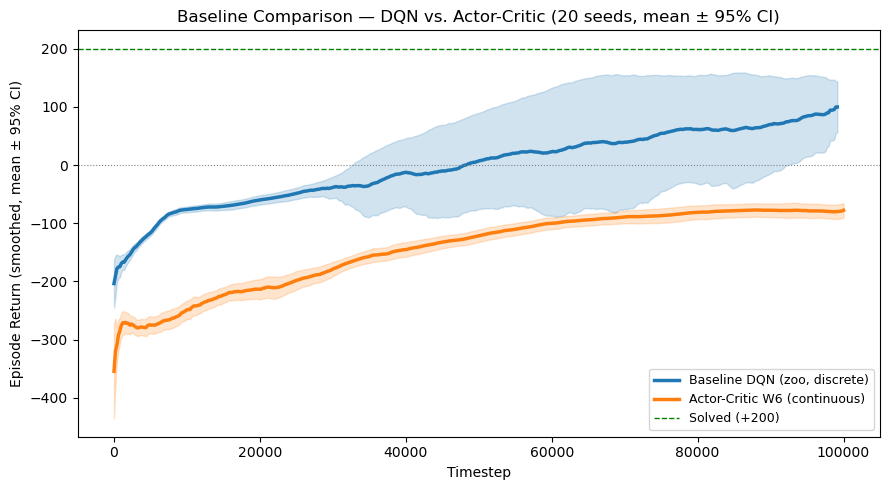

Saved: ../img/baseline_learning_curves.png


In [127]:
import numpy as np
import pandas as pd
import os

SEEDS = list(range(20))

# --- DQN baseline curves (already (N,2) format) ---
dqn_curves = []
for s in SEEDS:
    f = f"../data/baseline/curve_baseline_seed{s}.npy"
    if os.path.exists(f):
        dqn_curves.append(np.load(f))
print(f"DQN: loaded {len(dqn_curves)} seed curves.")

# --- Actor-Critic curves (csv -> (N,2): [global_step, episode_return]) ---
ac_dir = "../../W6/data/experiment"
ac_curves = []
for fname in sorted(os.listdir(ac_dir)):
    if not fname.startswith("exp_s") or not fname.endswith(".csv"):
        continue
    df = pd.read_csv(os.path.join(ac_dir, fname))
    ep = df.groupby("episode").agg(
        global_step=("global_step", "last"),
        episode_return=("episode_return", "last"),
    ).reset_index()
    ac_curves.append(ep[["global_step", "episode_return"]].values.astype(float))
print(f"AC: loaded {len(ac_curves)} seed curves.")

# --- Combined plot using plot_sweep-style logic ---
BASELINE_COLOR = "#1f77b4"
AC_COLOR = "#ff7f0e"

import matplotlib.pyplot as plt

def _interpolate(curves, window=50):
    max_ts = min(c[-1, 0] for c in curves)
    grid = np.linspace(0, max_ts, 500)
    interp = []
    for curve in curves:
        ts = curve[:, 0].astype(float)
        r  = smooth(curve[:, 1], window)
        valid = ~np.isnan(r)
        interp.append(np.interp(grid, ts[valid], r[valid]))
    mat  = np.array(interp)
    mean = mat.mean(axis=0)
    ci95 = 1.96 * mat.std(axis=0) / np.sqrt(len(mat))
    return grid, mean, ci95

fig, ax = plt.subplots(figsize=(9, 5))

for curves, color, label in [
    (dqn_curves, BASELINE_COLOR, "Baseline DQN (zoo, discrete)"),
    (ac_curves,  AC_COLOR,       "Actor-Critic W6 (continuous)"),
]:
    grid, mean, ci95 = _interpolate(curves, window=50)
    ax.plot(grid, mean, color=color, linewidth=2.5, label=label)
    ax.fill_between(grid, mean - ci95, mean + ci95, color=color, alpha=0.2)

ax.axhline(200, color="green", linestyle="--", linewidth=1, label="Solved (+200)")
ax.axhline(0,   color="gray",  linestyle=":",  linewidth=0.8)
ax.set_xlabel("Timestep")
ax.set_ylabel("Episode Return (smoothed, mean ± 95% CI)")
ax.set_title(f"Baseline Comparison — DQN vs. Actor-Critic (20 seeds, mean ± 95% CI)")
ax.legend(fontsize=9)
fig.tight_layout()
path = f"{IMG_DIR}/baseline_learning_curves.png"
fig.savefig(path, dpi=150)
plt.show()
print(f"Saved: {path}")


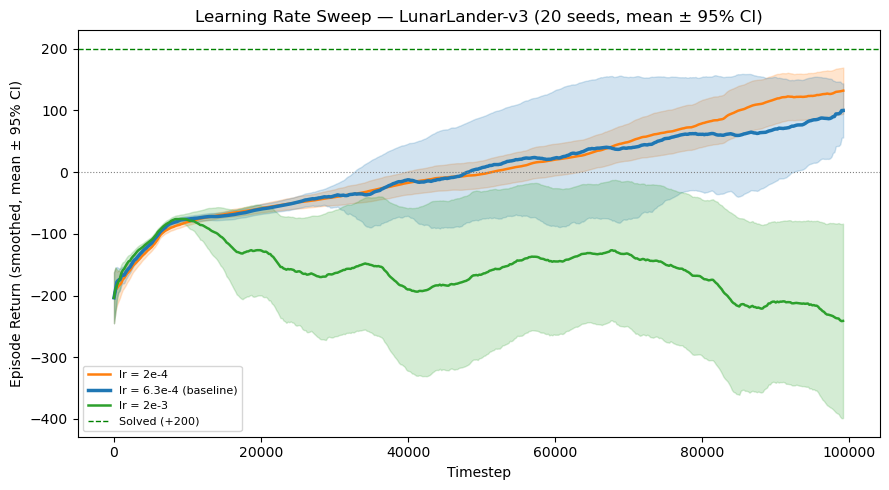

Saved: ../img/sweep_lr_learning_curves.png


In [128]:
plot_sweep(
    data_dir="../data/sweep_lr",
    tags=[
        ("lr2e-04",  "lr = 2e-4"),
        ("baseline", "lr = 6.3e-4 (baseline)", "../data/baseline"),
        ("lr2e-03",  "lr = 2e-3"),
    ],
    label_fmt="curve_{tag}_seed{s}.npy",
    title=f"Learning Rate Sweep — LunarLander-v3 ({len(SEEDS)} seeds, mean ± 95% CI)",
    filename="sweep_lr_learning_curves.png",
    baseline_tag="baseline",
    seeds=SEEDS
)

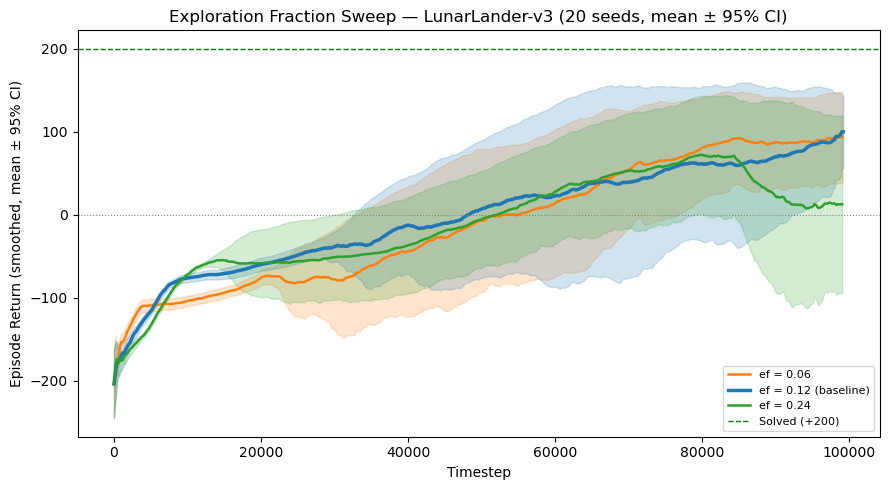

Saved: ../img/sweep_exploration_learning_curves.png


In [129]:
plot_sweep(
    data_dir="../data/sweep_exploration",
    tags=[
        ("ef0.06",   "ef = 0.06"),
        ("baseline", "ef = 0.12 (baseline)", "../data/baseline"),
        ("ef0.24",   "ef = 0.24"),
    ],
    label_fmt="curve_{tag}_seed{s}.npy",
    title=f"Exploration Fraction Sweep — LunarLander-v3 ({len(SEEDS)} seeds, mean ± 95% CI)",
    filename="sweep_exploration_learning_curves.png",
    baseline_tag="baseline",
    seeds=SEEDS,
)

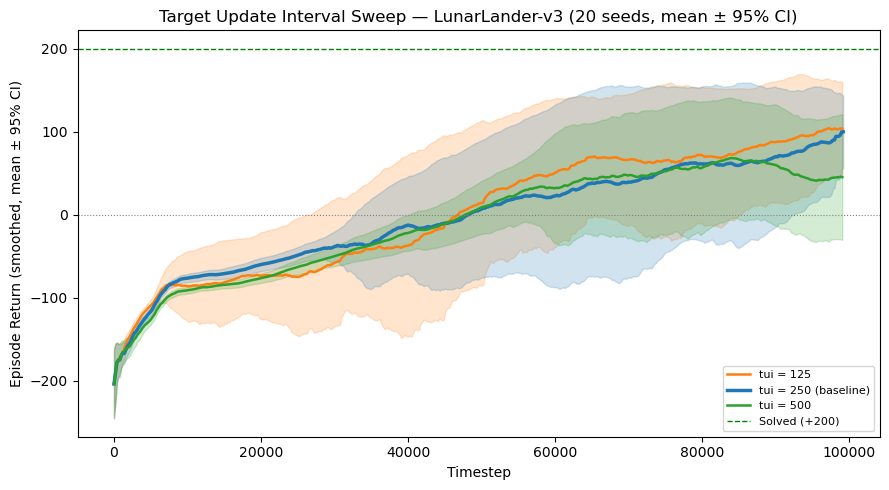

Saved: ../img/sweep_tui_learning_curves.png


In [131]:
plot_sweep(
    data_dir="../data/sweep_target_update",
    tags=[
        ("tui125",   "tui = 125"),
        ("baseline", "tui = 250 (baseline)", "../data/baseline"),
        ("tui500",   "tui = 500"),
    ],
    label_fmt="curve_{tag}_seed{s}.npy",
    title=f"Target Update Interval Sweep — LunarLander-v3 ({len(SEEDS)} seeds, mean ± 95% CI)",
    filename="sweep_tui_learning_curves.png",
    baseline_tag="baseline",
    seeds=SEEDS,
)

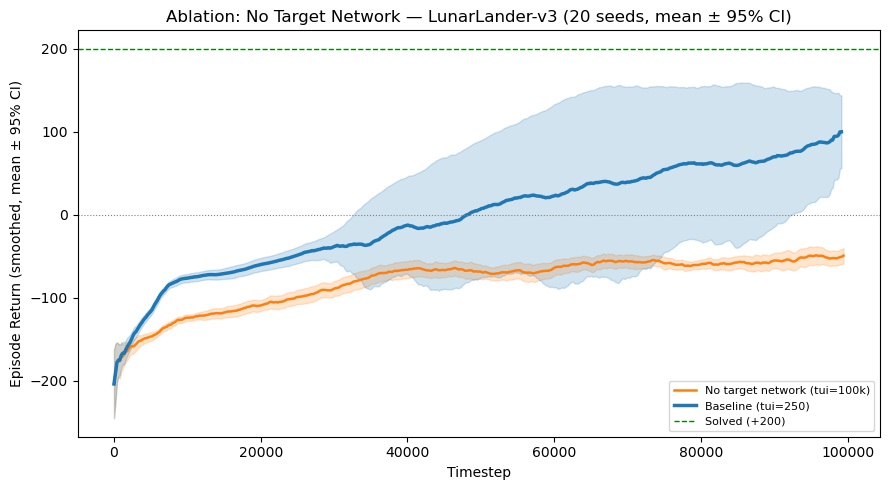

Saved: ../img/ablation_no_target_learning_curves.png


In [132]:
plot_sweep(
    data_dir="../data/ablation_no_target",
    tags=[
        ("no_target", "No target network (tui=100k)"),
        ("baseline",  "Baseline (tui=250)", "../data/baseline"),
    ],
    label_fmt="curve_{tag}_seed{s}.npy",
    title=f"Ablation: No Target Network — LunarLander-v3 ({len(SEEDS)} seeds, mean ± 95% CI)",
    filename="ablation_no_target_learning_curves.png",
    baseline_tag="baseline",
    seeds=SEEDS,
)

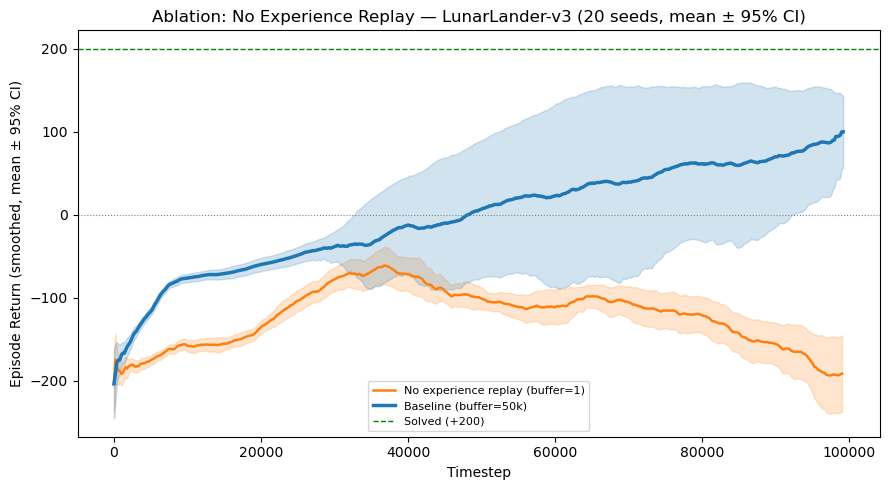

Saved: ../img/ablation_no_replay_learning_curves.png


In [133]:
plot_sweep(
    data_dir="../data/ablation_no_replay",
    tags=[
        ("no_replay", "No experience replay (buffer=1)"),
        ("baseline",  "Baseline (buffer=50k)", "../data/baseline"),
    ],
    label_fmt="curve_{tag}_seed{s}.npy",
    title=f"Ablation: No Experience Replay — LunarLander-v3 ({len(SEEDS)} seeds, mean ± 95% CI)",
    filename="ablation_no_replay_learning_curves.png",
    baseline_tag="baseline",
    seeds=SEEDS,
)

In [134]:
import numpy as np
import os

def final_return(path, n=10):
    """Mean of last n episode returns from a saved curve file."""
    curve = np.load(path)
    returns = curve[:, 1]
    return np.mean(returns[-n:]) if len(returns) >= n else np.mean(returns)

configs = [
    ("Baseline (lr=6.3e-4)",          "../data/baseline",              "curve_baseline_seed{s}.npy"),
    ("LR = 2e-4",                     "../data/sweep_lr",              "curve_lr2e-04_seed{s}.npy"),
    ("LR = 2e-3",                     "../data/sweep_lr",              "curve_lr2e-03_seed{s}.npy"),
    ("Exploration fraction = 0.06",   "../data/sweep_exploration",     "curve_ef0.06_seed{s}.npy"),
    ("Exploration fraction = 0.24",   "../data/sweep_exploration",     "curve_ef0.24_seed{s}.npy"),
    ("Target update interval = 125",  "../data/sweep_target_update",   "curve_tui125_seed{s}.npy"),
    ("Target update interval = 500",  "../data/sweep_target_update",   "curve_tui500_seed{s}.npy"),
    ("Ablation: no target network",   "../data/ablation_no_target",    "curve_no_target_seed{s}.npy"),
    ("Ablation: no experience replay","../data/ablation_no_replay",    "curve_no_replay_seed{s}.npy"),
]

header = f"{'Configuration':<42} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}"
print(header)
print("-" * len(header))

for label, data_dir, pattern in configs:
    seed_finals = [final_return(os.path.join(data_dir, pattern.format(s=s))) for s in SEEDS]
    print(f"{label:<42} {np.mean(seed_finals):>8.1f} {np.std(seed_finals):>8.1f} {np.min(seed_finals):>8.1f} {np.max(seed_finals):>8.1f}")

# W6 actor-critic (LunarLanderContinuous-v3, 20 seeds, 100k steps) — hardcoded from W6 experiment
print(f"{'Actor-Critic W6 (continuous actions)':<42} {-170.4:>8.1f} {19.2:>8.1f} {-213.1:>8.1f} {-132.9:>8.1f}")

Configuration                                  Mean      Std      Min      Max
------------------------------------------------------------------------------
Baseline (lr=6.3e-4)                          105.0    139.9   -291.7    247.6
LR = 2e-4                                     150.4     86.0    -33.7    255.1
LR = 2e-3                                    -335.4    542.2  -2132.2    187.6
Exploration fraction = 0.06                   114.8    131.3   -384.3    244.3
Exploration fraction = 0.24                    15.4    322.7  -1263.5    228.5
Target update interval = 125                  104.2    170.2   -476.4    212.6
Target update interval = 500                   44.2    193.2   -714.9    234.7
Ablation: no target network                   -43.8     37.1   -133.3     13.3
Ablation: no experience replay               -177.3    136.0   -628.2     20.3
Actor-Critic W6 (continuous actions)         -170.4     19.2   -213.1   -132.9


## 6. Baseline performance distribution

n=20  mean=105.0  median=160.4  std=139.9  skewness=-1.60


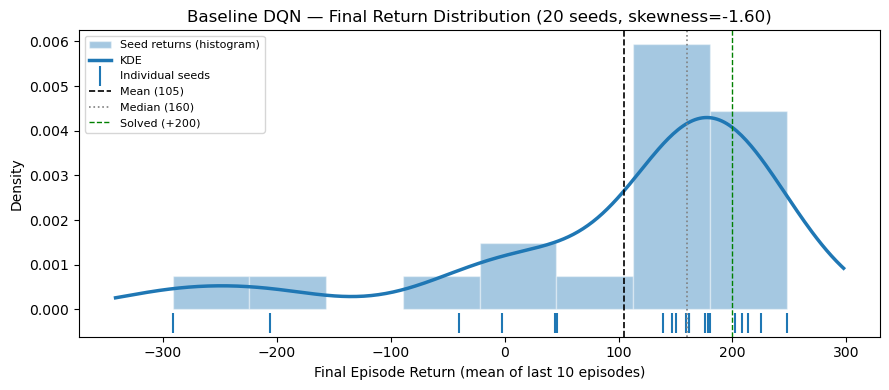

Saved: ../img/baseline_distribution.png


In [135]:
# TODO: Model the final-return distribution of the DQN baseline across 20 seeds.
# Outcome: histogram + KDE showing the shape (left-skewed, negative tail),
# with mean, median, and std annotated; saved to img/.
# DONE

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats
from scipy.stats import gaussian_kde

SEEDS = list(range(20))

finals = []
for s in SEEDS:
    c = np.load(f"../data/baseline/curve_baseline_seed{s}.npy")
    finals.append(np.mean(c[-10:, 1]))
finals = np.array(finals)

mean   = finals.mean()
median = np.median(finals)
std    = finals.std()
skew   = stats.skew(finals)

print(f"n={len(finals)}  mean={mean:.1f}  median={median:.1f}  std={std:.1f}  skewness={skew:.2f}")

# KDE
kde = gaussian_kde(finals, bw_method=0.4)
x   = np.linspace(finals.min() - 50, finals.max() + 50, 300)
y   = kde(x)

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(finals, bins=8, density=True, color=BASELINE_COLOR, alpha=0.4, edgecolor="white", label="Seed returns (histogram)")
ax.plot(x, y, color=BASELINE_COLOR, linewidth=2.5, label="KDE")
ax.plot(finals, np.zeros_like(finals) - 0.0003, "|", color=BASELINE_COLOR, markersize=14, markeredgewidth=1.5, label="Individual seeds")

ax.axvline(mean,   color="black",  linestyle="--", linewidth=1.2, label=f"Mean ({mean:.0f})")
ax.axvline(median, color="gray",   linestyle=":",  linewidth=1.2, label=f"Median ({median:.0f})")
ax.axvline(200,    color="green",  linestyle="--", linewidth=1,   label="Solved (+200)")

ax.set_xlabel("Final Episode Return (mean of last 10 episodes)")
ax.set_ylabel("Density")
ax.set_title(f"Baseline DQN — Final Return Distribution ({len(finals)} seeds, skewness={skew:.2f})")
ax.legend(fontsize=8)
fig.tight_layout()

path = f"{IMG_DIR}/baseline_distribution.png"
fig.savefig(path, dpi=150)
plt.show()
print(f"Saved: {path}")